# Notebook 11: SHAP Explainability and District Risk Factor Decomposition

Notebook 10 established that Random Forest achieves the best discriminative 
performance at ROC-AUC 0.6856 for stunting prediction in the 2024 Malawi DHS 
national sample. Knowing which model performs best is necessary but not sufficient 
for a PhD-level contribution. The more important question is why the model makes 
the predictions it does, and whether the reasons differ across geographies.

This notebook applies SHAP (SHapley Additive exPlanations) to the trained Random 
Forest model. SHAP values are grounded in cooperative game theory and assign each 
feature a contribution to each individual prediction. Unlike standard feature 
importance which tells you which features the model used most across all predictions, 
SHAP tells you how much each feature pushed each individual prediction toward or 
away from stunting, and in which direction.

Three analytical layers are produced here.

Global SHAP analysis identifies the overall importance and direction of each 
predictor across the full national sample. This answers the question of which 
factors matter most for stunting prediction in Malawi as a whole.

District-level SHAP decomposition aggregates individual SHAP values by district 
to identify which risk factors dominate in each of the 28 districts and 4 cities. 
This answers the question of whether the same intervention would be equally 
effective everywhere, or whether district-specific targeting is warranted.

SHAP interaction analysis examines how pairs of features jointly influence 
predictions, capturing the non-linear interactions that individual feature 
importance misses.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import shap
import joblib
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

PROJECT_ROOT   = Path("/Users/frack/Documents/PhD Data Science/malawi-dhs-2024-geoai")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS         = PROJECT_ROOT / "outputs" / "models"
FIGURES        = PROJECT_ROOT / "outputs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PROCESSED / "model_ready_stunting_v2.parquet")
rf = joblib.load(MODELS / "rf_stunting_v2.pkl")

FEATURES = [
    "imm_child_age_months", "enc_age_band", "enc_child_sex",
    "imm_birth_order", "imm_birth_interval", "imm_first_born",
    "imm_short_interval", "imm_high_birth_order",
    "enc_size_at_birth", "enc_had_diarrhea",
    "und_maternal_age", "und_maternal_edu_years", "enc_edu_level",
    "und_maternal_weight_kg", "und_maternal_height_cm",
    "und_maternal_bmi", "und_low_bmi", "und_maternal_stunted",
    "und_total_children", "und_household_size",
    "enc_wealth_index", "enc_residence", "enc_region",
    "enc_district", "enc_religion",
    "district_stunting_rate", "district_mean_age",
    "district_mean_wealth", "district_mean_mat_height"
]

X = df[FEATURES]
y = df["outcome_stunted"]

print("Dataset:", df.shape)
print("Features:", len(FEATURES))
print("SHAP version:", shap.__version__)

Dataset: (5122, 36)
Features: 29
SHAP version: 0.49.1


/Users/frack/miniforge3/envs/ocr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Computing SHAP values

SHAP TreeExplainer is used for the Random Forest model. It computes exact Shapley 
values using the tree structure directly, which is more accurate and faster than 
the model-agnostic KernelExplainer. Computing SHAP values for all 5,122 records 
takes a few minutes. A progress indicator is printed every 1,000 records.

SHAP values are computed for the positive class, that is the probability of being 
stunted. A positive SHAP value for a feature means that feature pushed the 
prediction toward stunting for that child. A negative value means it pushed away 
from stunting.

In [2]:
print("Initialising SHAP TreeExplainer...")
explainer = shap.TreeExplainer(rf)

print("Computing SHAP values for all records (this takes a few minutes)...")
shap_values = explainer.shap_values(X)

# newer SHAP versions return 3D array (n_samples, n_features, n_classes)
# for binary classification we take index 1 for the positive class
if isinstance(shap_values, list):
    shap_pos = shap_values[1]
elif shap_values.ndim == 3:
    shap_pos = shap_values[:, :, 1]
else:
    shap_pos = shap_values

print(f"SHAP values shape: {shap_pos.shape}")
print(f"Expected value (base rate): {explainer.expected_value[1]:.4f}")
print(f"Actual stunting rate: {y.mean():.4f}")

shap_df = pd.DataFrame(shap_pos, columns=FEATURES)
shap_df["str_district"] = df["str_district"].values
shap_df["str_region"]   = df["str_region"].values
shap_df["outcome"]      = y.values

print("\nSHAP dataframe created:", shap_df.shape)
print("\nMean absolute SHAP by feature (top 10):")
mean_abs = shap_df[FEATURES].abs().mean().sort_values(ascending=False)
print(mean_abs.head(10).round(4))

Initialising SHAP TreeExplainer...
Computing SHAP values for all records (this takes a few minutes)...
SHAP values shape: (5122, 29)
Expected value (base rate): 0.5179
Actual stunting rate: 0.3579

SHAP dataframe created: (5122, 32)

Mean absolute SHAP by feature (top 10):
und_maternal_height_cm    0.0558
imm_child_age_months      0.0394
und_maternal_weight_kg    0.0334
enc_age_band              0.0268
district_stunting_rate    0.0257
und_maternal_bmi          0.0138
und_maternal_edu_years    0.0135
imm_birth_interval        0.0134
enc_wealth_index          0.0123
und_maternal_age          0.0097
dtype: float64


## Global SHAP analysis

Two standard SHAP visualisations are produced for the global analysis.

The beeswarm plot shows every child as a dot. The horizontal position is the SHAP 
value for that feature, showing how much it pushed the prediction. The colour shows 
the actual feature value for that child, with red meaning high and blue meaning low. 
This plot reveals both the importance and the direction of each feature's effect.

The mean absolute SHAP bar chart gives a cleaner ranking of overall feature 
importance across the dataset. This is the figure most suitable for a thesis 
results section or a policy brief.

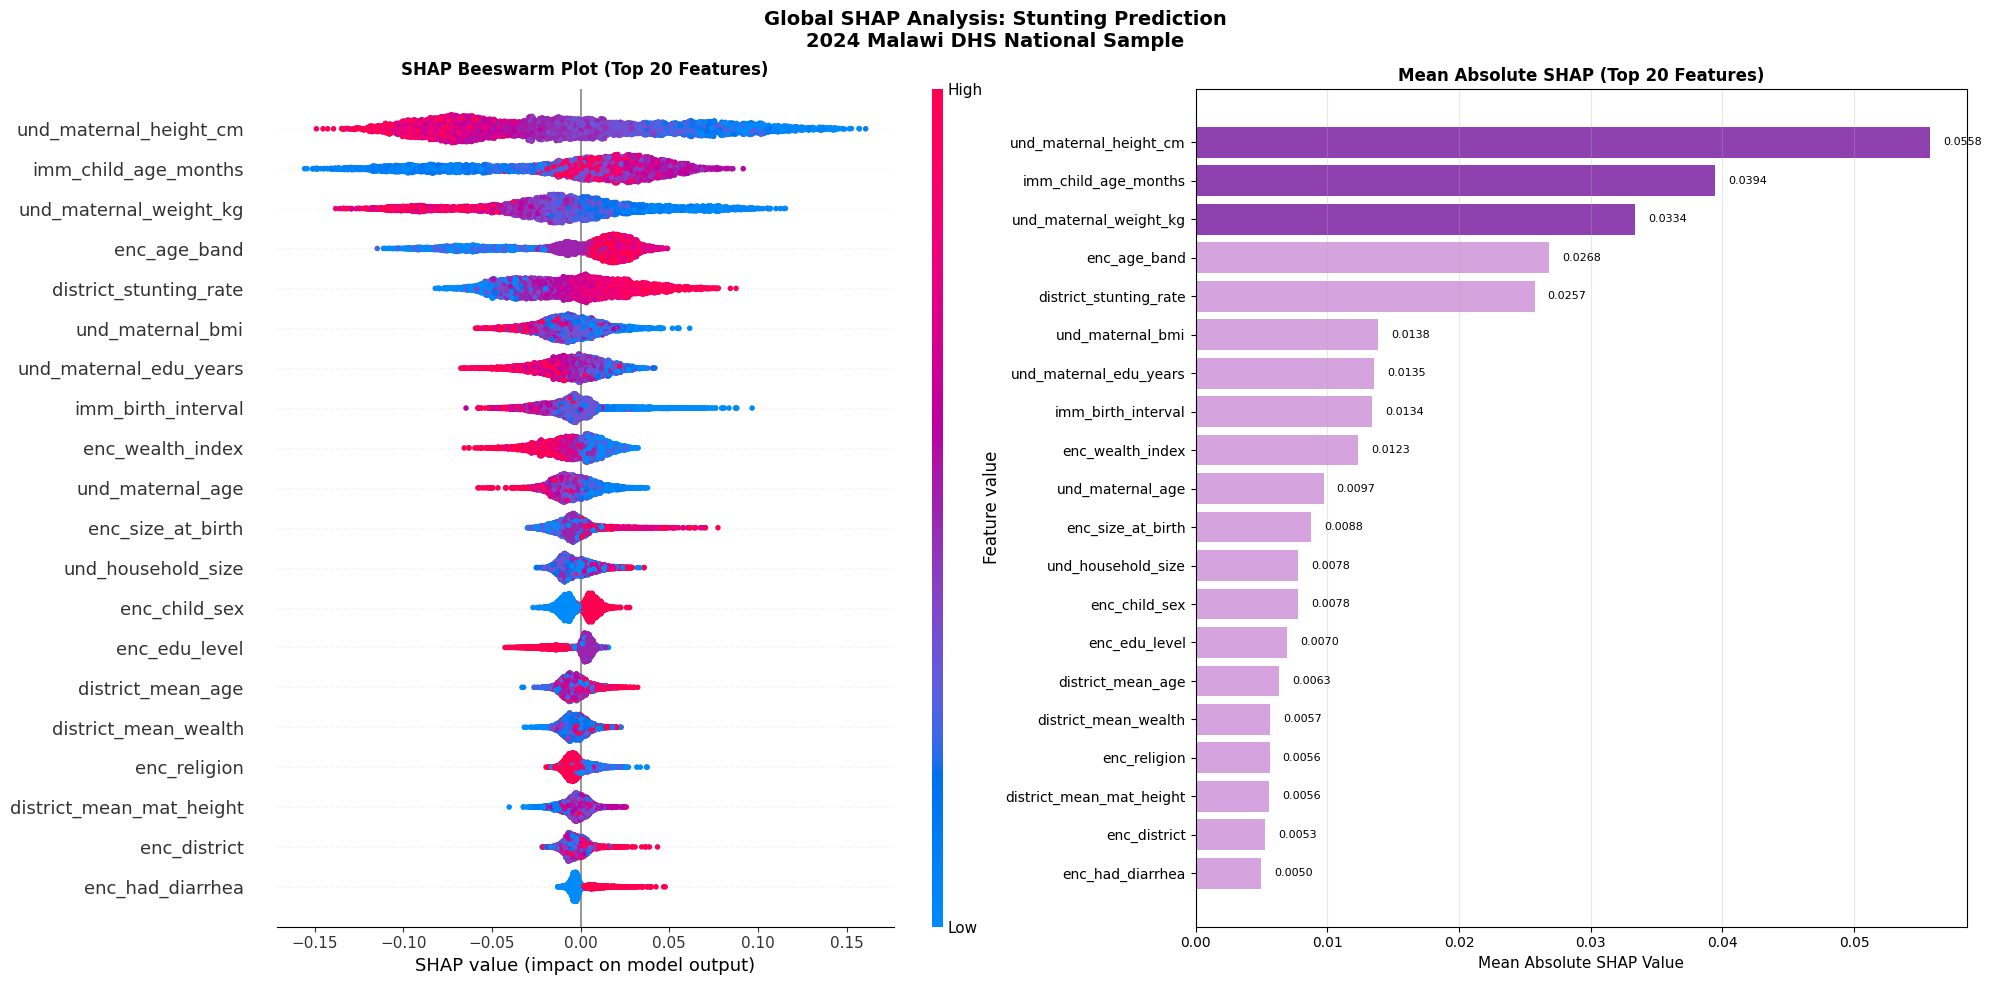

Saved: shap_global_analysis.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("Global SHAP Analysis: Stunting Prediction\n2024 Malawi DHS National Sample",
             fontsize=14, fontweight="bold")

# beeswarm plot
plt.sca(axes[0])
shap.summary_plot(
    shap_pos, X,
    feature_names=FEATURES,
    max_display=20,
    show=False,
    plot_size=None
)
axes[0].set_title("SHAP Beeswarm Plot (Top 20 Features)",
                  fontsize=12, fontweight="bold", pad=10)

# mean absolute SHAP bar chart
mean_shap = shap_df[FEATURES].abs().mean().sort_values(ascending=True).tail(20)
colors    = ["#7B1FA2" if v > 0.03 else "#CE93D8" for v in mean_shap.values]

axes[1].barh(mean_shap.index, mean_shap.values, color=colors, alpha=0.85)
axes[1].set_xlabel("Mean Absolute SHAP Value", fontsize=11)
axes[1].set_title("Mean Absolute SHAP (Top 20 Features)",
                  fontsize=12, fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

for i, (feat, val) in enumerate(mean_shap.items()):
    axes[1].text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "shap_global_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_global_analysis.png")

## SHAP dependence plots for top predictors

Dependence plots show how the SHAP value for a single feature changes as its 
value changes across all children. The colour of each point shows a second 
feature that SHAP automatically selects as the strongest interaction partner. 
This reveals whether the effect of a predictor is linear, non-linear, or 
conditional on another variable.

The four plots cover the top predictors: maternal height, child age, maternal 
BMI, and district stunting rate. These are the variables where understanding 
the shape of the relationship is most important for intervention design.

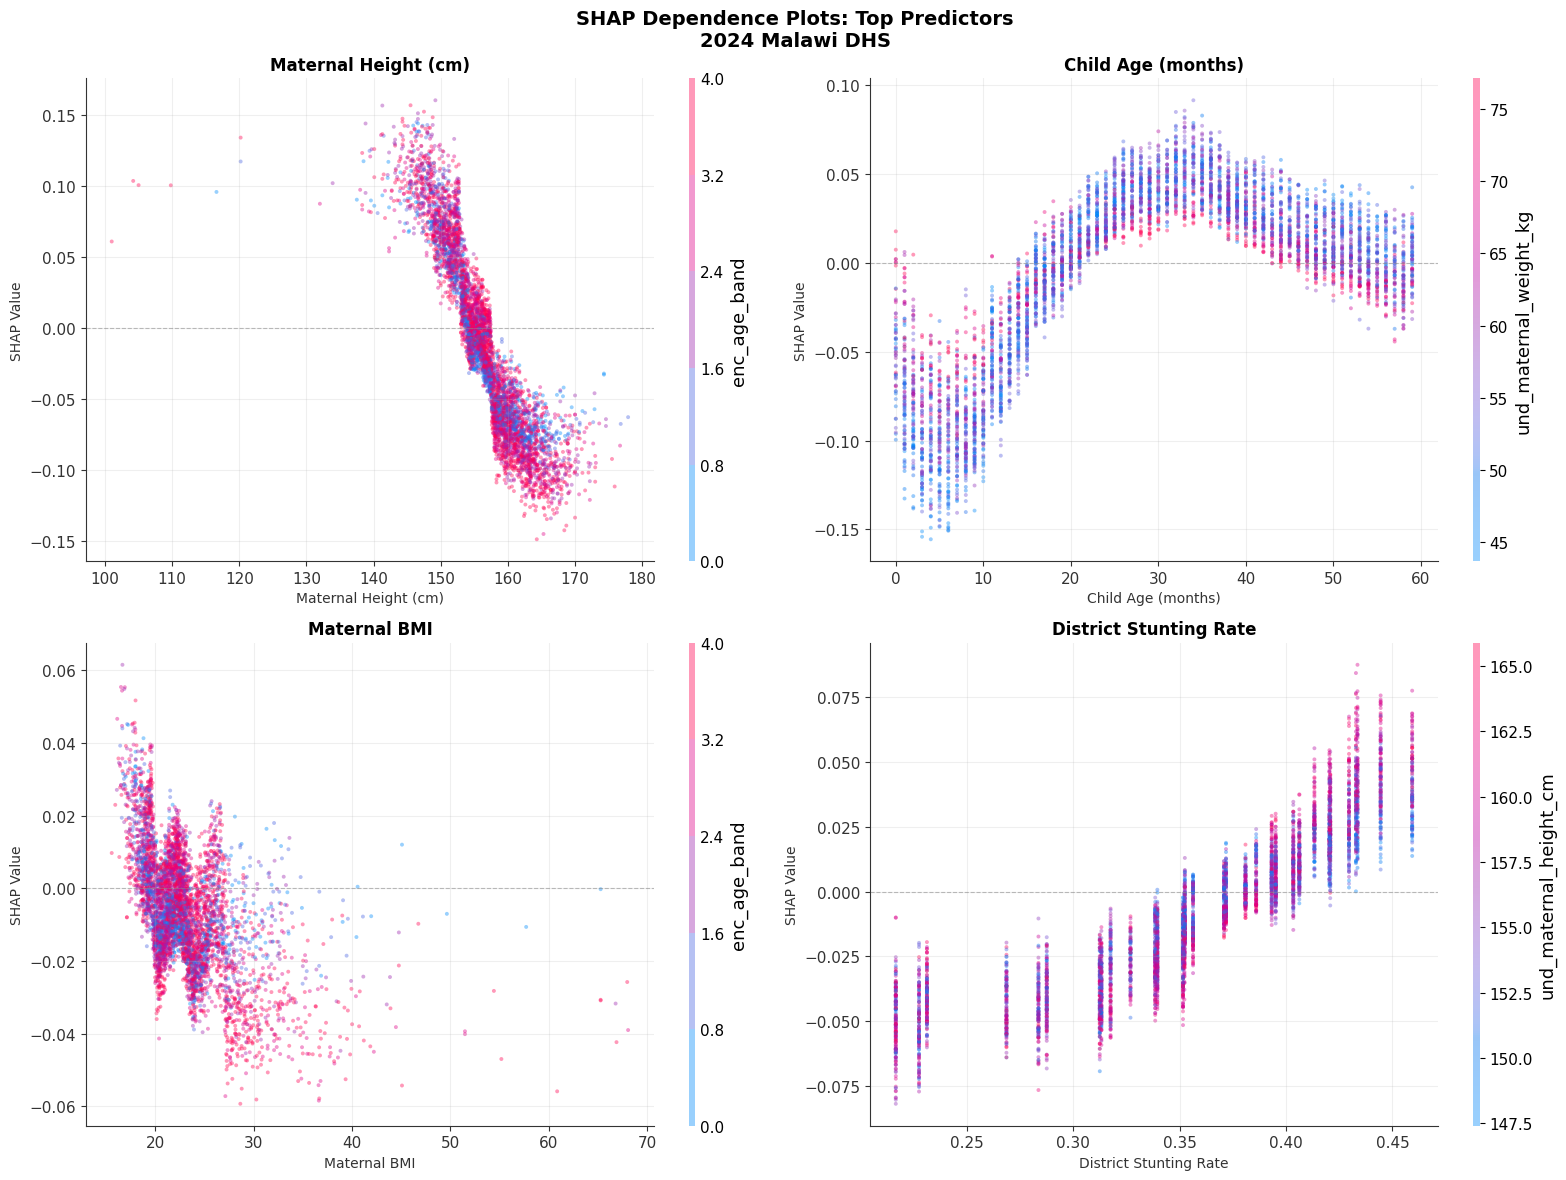

Saved: shap_dependence_plots.png


In [4]:
top_features = [
    "und_maternal_height_cm",
    "imm_child_age_months",
    "und_maternal_bmi",
    "district_stunting_rate"
]

feature_labels = {
    "und_maternal_height_cm" : "Maternal Height (cm)",
    "imm_child_age_months"   : "Child Age (months)",
    "und_maternal_bmi"       : "Maternal BMI",
    "district_stunting_rate" : "District Stunting Rate"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("SHAP Dependence Plots: Top Predictors\n2024 Malawi DHS",
             fontsize=14, fontweight="bold")

for ax, feat in zip(axes.flatten(), top_features):
    shap.dependence_plot(
        feat, shap_pos, X,
        feature_names=FEATURES,
        ax=ax, show=False,
        alpha=0.4, dot_size=8
    )
    ax.set_title(feature_labels[feat], fontsize=12, fontweight="bold")
    ax.set_xlabel(feature_labels[feat], fontsize=10)
    ax.set_ylabel("SHAP Value", fontsize=10)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURES / "shap_dependence_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_dependence_plots.png")

## District-level SHAP decomposition

This is the core policy contribution of the notebook. SHAP values are aggregated 
by district to produce a mean absolute SHAP profile for each of the 28 districts 
and 4 cities. This shows which features are driving stunting predictions in each 
district, and whether the dominant pathway differs geographically.

The heatmap displays the top 10 predictors across all districts. Districts are 
sorted by their overall stunting rate from highest to lowest. Features are sorted 
by their mean absolute SHAP across all districts. The colour intensity shows how 
much each feature contributed to stunting predictions in that district, with darker 
colours indicating stronger influence.

This output directly answers the sub-national heterogeneity research objective: 
do the same risk factors dominate everywhere, or does each district require a 
different intervention emphasis.

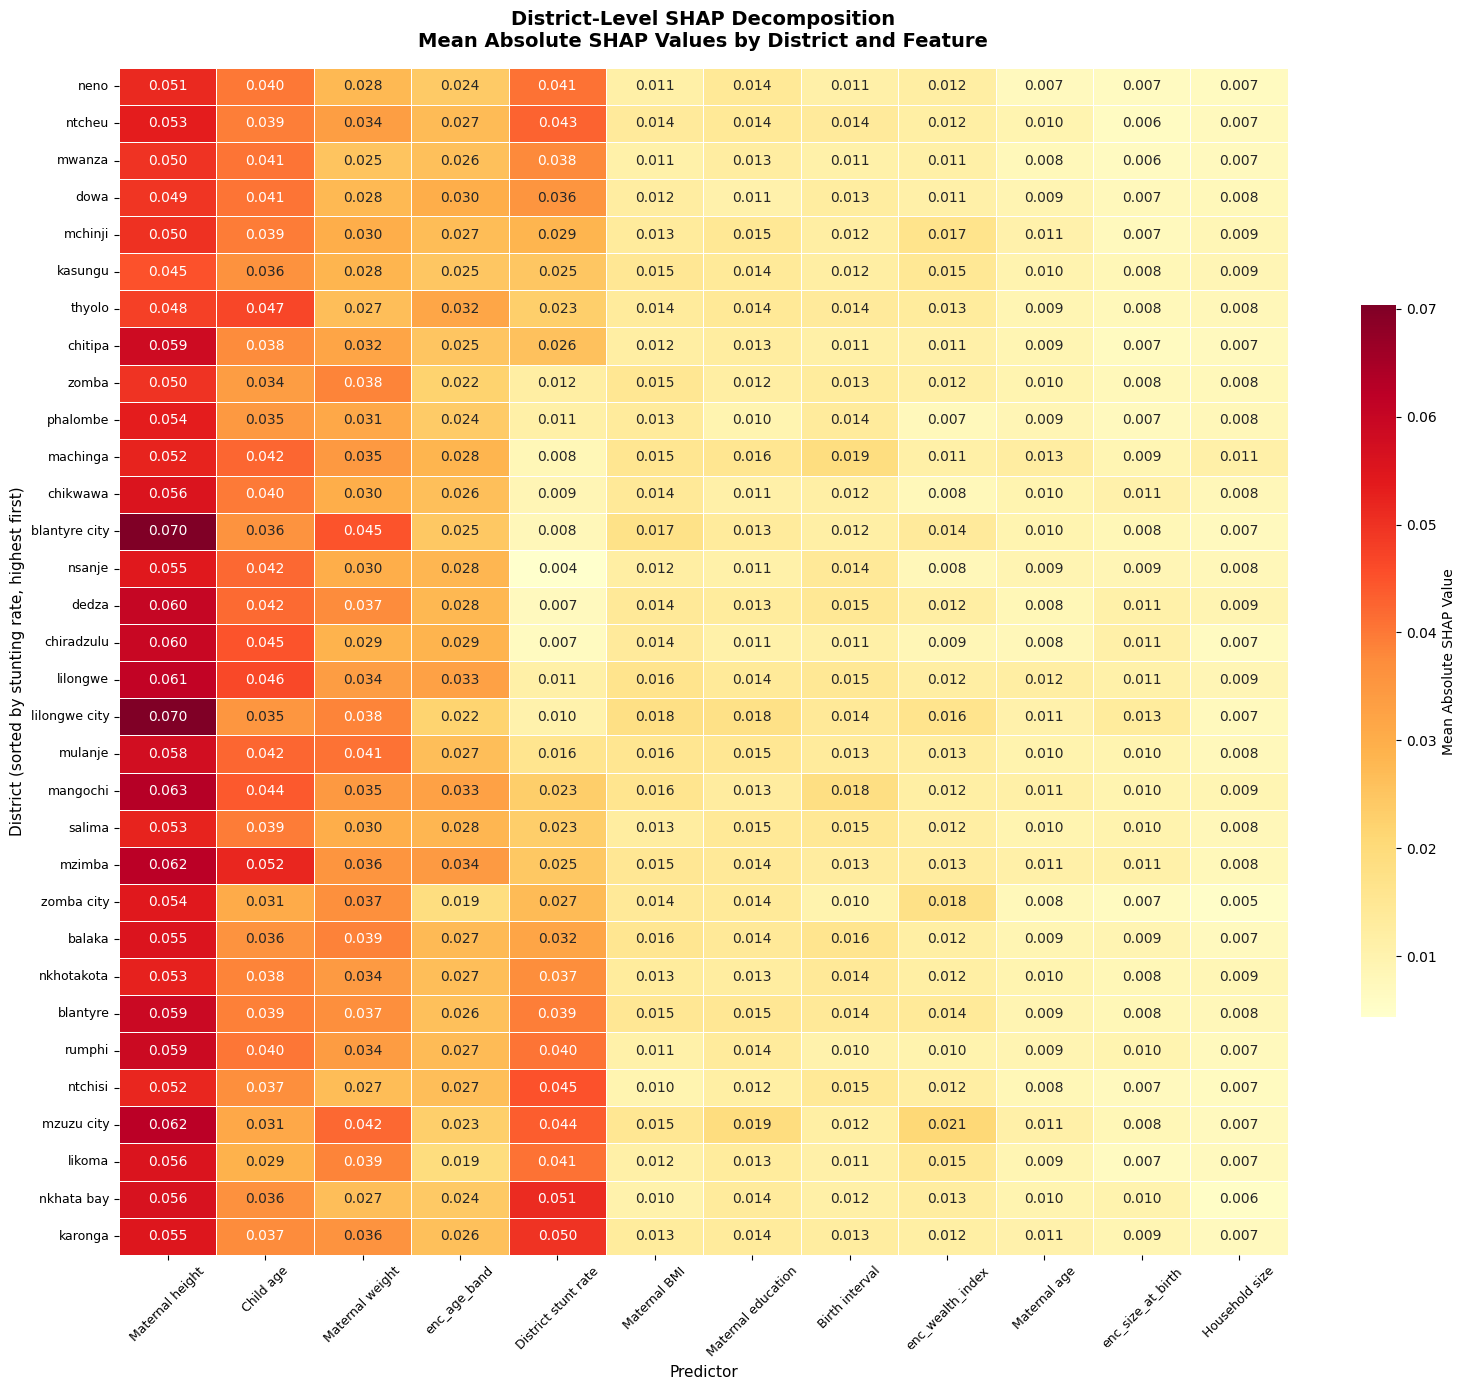

Saved: shap_district_decomposition.png


In [5]:
# compute mean absolute SHAP by district
district_shap = (shap_df.groupby("str_district")[FEATURES]
                 .apply(lambda x: x.abs().mean())
                 .reset_index())

# get district stunting rates for ordering
district_rates = (df.groupby("str_district")["outcome_stunted"]
                  .mean()
                  .reset_index()
                  .rename(columns={"outcome_stunted": "stunting_rate"}))

district_shap = district_shap.merge(district_rates, on="str_district")
district_shap = district_shap.sort_values("stunting_rate", ascending=False)

# select top 12 features by mean absolute SHAP
top12 = (shap_df[FEATURES].abs().mean()
         .sort_values(ascending=False)
         .head(12).index.tolist())

heatmap_data = district_shap.set_index("str_district")[top12]

# clean feature names for display
clean_names = {
    "und_maternal_height_cm" : "Maternal height",
    "imm_child_age_months"   : "Child age",
    "und_maternal_bmi"       : "Maternal BMI",
    "und_maternal_weight_kg" : "Maternal weight",
    "imm_birth_interval"     : "Birth interval",
    "und_maternal_age"       : "Maternal age",
    "und_maternal_edu_years" : "Maternal education",
    "district_stunting_rate" : "District stunt rate",
    "district_mean_mat_height": "District mat height",
    "district_mean_wealth"   : "District wealth",
    "district_mean_age"      : "District mean age",
    "und_household_size"     : "Household size"
}
heatmap_data.columns = [clean_names.get(c, c) for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".3f",
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "Mean Absolute SHAP Value", "shrink": 0.6}
)

ax.set_title("District-Level SHAP Decomposition\nMean Absolute SHAP Values by District and Feature",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Predictor", fontsize=11)
ax.set_ylabel("District (sorted by stunting rate, highest first)", fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "shap_district_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_district_decomposition.png")

## District risk profile clustering

To make the district decomposition actionable for policy, districts are grouped 
into clusters based on their SHAP profiles. Districts within the same cluster 
share similar dominant risk factor patterns and are likely to respond similarly 
to the same intervention. Districts in different clusters require different 
intervention emphases.

K-means clustering with three clusters is applied to the district SHAP profiles. 
Three clusters is consistent with the scale of Malawi's district landscape and 
allows for meaningful differentiation without over-fragmenting the policy space.

Districts by cluster:

Cluster A (mean stunting rate: 0.335):
  mchinji: 0.430
  kasungu: 0.421
  zomba: 0.406
  blantyre city: 0.386
  lilongwe city: 0.352
  mulanje: 0.352
  zomba city: 0.327
  balaka: 0.318
  blantyre: 0.312
  mzuzu city: 0.269
  likoma: 0.231
  karonga: 0.217

Cluster B (mean stunting rate: 0.374):
  neno: 0.459
  ntcheu: 0.444
  mwanza: 0.434
  dowa: 0.433
  thyolo: 0.420
  chitipa: 0.413
  phalombe: 0.403
  chikwawa: 0.393
  nsanje: 0.381
  chiradzulu: 0.371
  salima: 0.340
  nkhotakota: 0.313
  rumphi: 0.288
  ntchisi: 0.284
  nkhata bay: 0.228

Cluster C (mean stunting rate: 0.363):
  machinga: 0.395
  dedza: 0.372
  lilongwe: 0.356
  mangochi: 0.352
  mzimba: 0.339


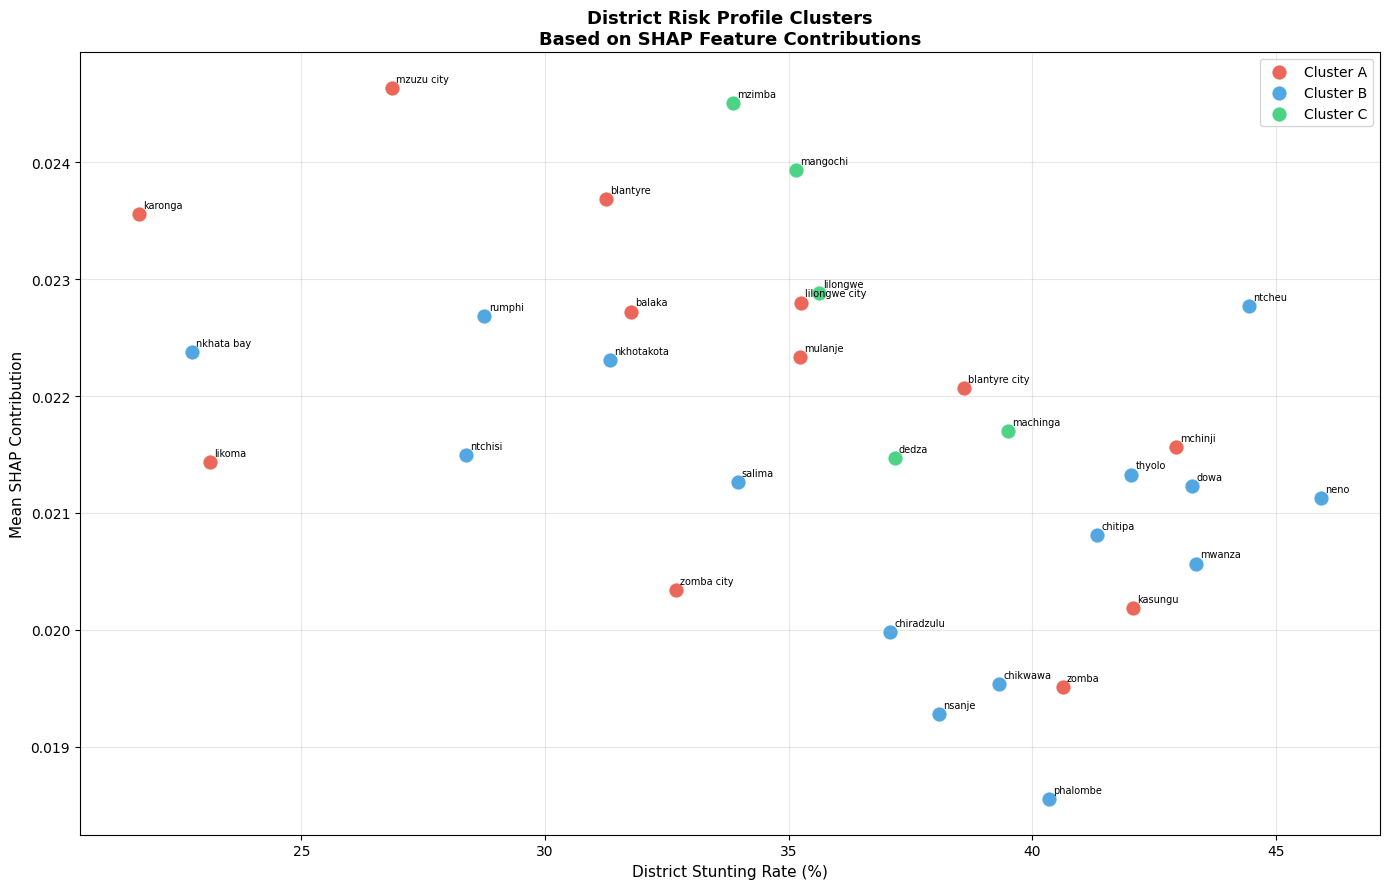

Saved: shap_district_clusters.png


In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

shap_matrix = district_shap.set_index("str_district")[top12].values
scaler      = StandardScaler()
shap_scaled = scaler.fit_transform(shap_matrix)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
district_shap["cluster"] = kmeans.fit_predict(shap_scaled)

cluster_labels = {0: "Cluster A", 1: "Cluster B", 2: "Cluster C"}
district_shap["cluster_label"] = district_shap["cluster"].map(cluster_labels)

print("Districts by cluster:")
for cluster in sorted(district_shap["cluster"].unique()):
    label  = cluster_labels[cluster]
    dists  = district_shap[district_shap["cluster"] == cluster]["str_district"].tolist()
    rates  = district_shap[district_shap["cluster"] == cluster]["stunting_rate"].values
    print(f"\n{label} (mean stunting rate: {rates.mean():.3f}):")
    for d, r in zip(dists, rates):
        print(f"  {d}: {r:.3f}")

fig, ax = plt.subplots(figsize=(14, 9))

cluster_colors = {0: "#e74c3c", 1: "#3498db", 2: "#2ecc71"}
for cluster in sorted(district_shap["cluster"].unique()):
    subset = district_shap[district_shap["cluster"] == cluster]
    ax.scatter(
        subset["stunting_rate"] * 100,
        subset[top12].mean(axis=1),
        c=cluster_colors[cluster],
        label=cluster_labels[cluster],
        s=120, alpha=0.85, edgecolors="white", linewidth=0.8
    )
    for _, row in subset.iterrows():
        ax.annotate(
            row["str_district"],
            (row["stunting_rate"] * 100, row[top12].mean()),
            fontsize=7, ha="left", va="bottom",
            xytext=(3, 3), textcoords="offset points"
        )

ax.set_xlabel("District Stunting Rate (%)", fontsize=11)
ax.set_ylabel("Mean SHAP Contribution", fontsize=11)
ax.set_title("District Risk Profile Clusters\nBased on SHAP Feature Contributions",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "shap_district_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_district_clusters.png")

## Saving SHAP outputs and summary

All SHAP values and district decomposition results are saved for use in downstream 
notebooks and for reporting.

In [7]:
# save full SHAP values
shap_df.to_parquet(DATA_PROCESSED / "shap_values_stunting.parquet", index=False)
print("Saved: shap_values_stunting.parquet")

# save district decomposition
district_shap.to_csv(
    PROJECT_ROOT / "outputs" / "shap_district_decomposition.csv",
    index=False
)
print("Saved: shap_district_decomposition.csv")

# print summary
print("\n=== SHAP Global Summary (top 10) ===")
global_importance = (shap_df[FEATURES].abs().mean()
                     .sort_values(ascending=False)
                     .head(10))
for feat, val in global_importance.items():
    clean = clean_names.get(feat, feat)
    print(f"  {clean:<30} {val:.4f}")

print("\n=== District Cluster Summary ===")
cluster_summary = (district_shap.groupby("cluster_label")
                   .agg(
                       n_districts   = ("str_district", "count"),
                       mean_stunting = ("stunting_rate", "mean"),
                       min_stunting  = ("stunting_rate", "min"),
                       max_stunting  = ("stunting_rate", "max")
                   ))
print(cluster_summary.round(3))

print("\n=== Figures saved ===")
for f in sorted(FIGURES.glob("shap_*.png")):
    print(" ", f.name)

Saved: shap_values_stunting.parquet
Saved: shap_district_decomposition.csv

=== SHAP Global Summary (top 10) ===
  Maternal height                0.0558
  Child age                      0.0394
  Maternal weight                0.0334
  enc_age_band                   0.0268
  District stunt rate            0.0257
  Maternal BMI                   0.0138
  Maternal education             0.0135
  Birth interval                 0.0134
  enc_wealth_index               0.0123
  Maternal age                   0.0097

=== District Cluster Summary ===
               n_districts  mean_stunting  min_stunting  max_stunting
cluster_label                                                        
Cluster A               12          0.335         0.217         0.430
Cluster B               15          0.374         0.228         0.459
Cluster C                5          0.363         0.339         0.395

=== Figures saved ===
  shap_dependence_plots.png
  shap_district_clusters.png
  shap_district_decompo

## Summary and Interpretation

The SHAP values answer a question that ROC-AUC cannot: not just how well the model 
predicts, but what it is actually responding to, and whether it is responding to 
the same things in Neno as it is in Karonga.

Maternal height came out on top globally at mean absolute SHAP 0.0558. The dependence 
plot shows why this variable carries so much weight. Below 150cm the values are 
strongly positive across almost every child in the sample. Between 150 and 160cm 
the effect weakens fast. Above 165cm it flattens out near zero. So it is not that 
taller mothers are slightly better, it is that below roughly 155cm the risk is 
substantially elevated and above 165cm the model barely responds to height at all. 
That kind of shape is useful for targeting. A maternal nutrition programme that 
prioritises women below 155cm is going after the group where height is actually 
doing the most damage in predictions.

Child age tells the 1000-day story clearly. SHAP values are negative or near zero 
in the first five months, meaning young infants are not being pushed toward stunting 
by their age. That changes around 6 months and the values climb through the 12 to 
24 month window. After 36 months they start coming back down, not because the child 
is recovering but because the damage from that window has already been absorbed into 
the other features. The colour on that plot is also telling. Children with heavier 
mothers show slightly lower SHAP values in the early months, which makes sense given 
what we know about maternal reserves and breastfeeding quality.

District stunting rate ranking fifth globally was the result I was most interested 
in. A SHAP of 0.0257 for a contextual variable means the model learned that knowing 
which district a child lives in, and how burdened that district already is, adds 
real signal on top of everything you know about the individual child and their mother. 
The dependence plot shows a clean near-linear relationship with no clustering or 
jumps. That kind of smooth response usually means the variable is picking up something 
real and diffuse, shared water sources, food market access, agro-ecological conditions, 
rather than a specific measured characteristic.

The heatmap and cluster analysis are where the policy implications become concrete. 
Maternal height and child age sit at the top of every single district. That part is 
consistent everywhere. What varies is how much the district-level contextual features 
contribute relative to individual maternal characteristics.

Cluster B is the 15 highest-burden districts, Neno, Ntcheu, Mwanza, Dowa, and others 
all above 40%. In these districts the district stunting rate and district maternal 
height contribute more relative to individual features than they do in Cluster A 
districts. That pattern suggests the shared environment in these districts is doing 
extra work. Better roads to markets, cleaner water infrastructure, and community-level 
food security programmes are more likely to move the needle here than clinic-based 
individual nutrition counselling alone.

Cluster A districts, Karonga, Likoma, Mzuzu City, and others with lower stunting 
rates, show SHAP profiles that are more cleanly driven by individual maternal 
characteristics. These are the districts where well-targeted antenatal care and 
maternal nutrition supplementation would have the clearest pathway to impact.

Cluster C sits in between and probably warrants its own closer look. Machinga, 
Dedza, Mzimba, Mangochi, and Lilongwe show mixed profiles that do not fit cleanly 
into either of the other two patterns. These may be places where stunting is 
geographically concentrated within the district rather than uniformly distributed, 
which the GPS cluster analysis in notebook 13 should help untangle.

The broader point is that running one national stunting programme with the same 
design everywhere is leaving effectiveness on the table. The SHAP decomposition 
gives you the evidence to argue for differentiated programming, and that is a 
contribution this analysis can make directly to whoever is designing the next cycle 
of nutrition interventions in Malawi.